# 08 — Ensemble Methods: Stacking & Weighted Average

## Methods
1. **Stacking Ensemble** — Out-of-fold predictions from base models → Ridge meta-learner
2. **Weighted Average Ensemble** — L-BFGS-B optimized weights across all trained models

## Base Models
- Classical: Ridge, RandomForest, XGBoost, LightGBM
- Deep: LSTM, BatteryGPT, iTransformer, VAE-LSTM

Ensemble theory: combining diverse learners reduces variance and captures different degradation patterns.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import joblib
import torch

from src.models.ensemble.stacking import StackingEnsemble, WeightedAverageEnsemble
from src.evaluation.metrics import regression_metrics, tolerance_accuracy, build_summary_table
from src.utils.plotting import save_fig, plot_actual_vs_predicted, plot_model_comparison_bars
from src.utils.config import ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR, get_version_paths, ensure_version_dirs

plt.style.use("seaborn-v0_8-whitegrid")

# v2 paths
v2 = get_version_paths('v2')
ensure_version_dirs('v2')

## 1. Load Pre-trained Predictions
We load saved predictions from all previously trained models.

In [2]:
# Load sequence data (same split as all DL notebooks)
data = np.load(str(ARTIFACTS_DIR / "battery_sequences.npz"), allow_pickle=True)
X_multi = data["X_multi"]
y_multi = data["y_multi"]
bids = data["bids_multi"]

# -- v2: intra-battery chronological split --
# For each battery, first 80% of sequences -> train, last 20% -> test
train_idx, test_idx = [], []
for bid in np.unique(bids):
    idxs = np.where(bids == bid)[0]
    n = len(idxs)
    cut = int(0.8 * n)
    train_idx.extend(idxs[:cut].tolist())
    test_idx.extend(idxs[cut:].tolist())

train_idx = np.array(train_idx)
test_idx = np.array(test_idx)

X_train, y_train = X_multi[train_idx], y_multi[train_idx]
X_test, y_test = X_multi[test_idx], y_multi[test_idx]

from sklearn.preprocessing import StandardScaler
n_samples, seq_len, n_feat = X_train.shape
scaler = StandardScaler().fit(X_train.reshape(-1, n_feat))
X_train_scaled = scaler.transform(X_train.reshape(-1, n_feat)).reshape(n_samples, seq_len, n_feat)
X_test_scaled = scaler.transform(X_test.reshape(-1, n_feat)).reshape(X_test.shape[0], seq_len, n_feat)

print(f"Sequence train: {X_train.shape} | test: {X_test.shape}")
print(f"n_features={n_feat}, seq_len={seq_len}")

Sequence train: (1444, 32, 12) | test: (290, 32, 12)
n_features=12, seq_len=32


## 2. Collect Base Model Predictions

In [3]:
from src.models.deep.lstm import VanillaLSTM, AttentionLSTM, BidirectionalLSTM
from src.models.deep.transformer import BatteryGPT, TemporalFusionTransformer
from src.models.deep.vae_lstm import VAE_LSTM
from src.utils.config import (
    LSTM_HIDDEN, LSTM_LAYERS, DROPOUT,
    TRANSFORMER_D_MODEL, TRANSFORMER_NHEAD, TRANSFORMER_LAYERS, WINDOW_SIZE,
    LATENT_DIM,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Helper: load PyTorch model and predict
def predict_pytorch(model_cls, checkpoint, X, post_fn=None, **kwargs):
    """Load a saved model and run inference."""
    model = model_cls(**kwargs)
    model.load_state_dict(torch.load(checkpoint, map_location=device, weights_only=True))
    model.to(device).eval()
    with torch.no_grad():
        out = model(torch.FloatTensor(X).to(device))
        if isinstance(out, dict):
            out = out["health_pred"]
        preds = out.cpu().numpy().flatten()
    if post_fn:
        preds = post_fn(preds)
    return preds

# ── Deep models registry ──
# Note: BatteryGPT was trained with max_len inferred from checkpoint
deep_registry = {
    "vanilla_lstm": (VanillaLSTM, dict(input_dim=n_feat, hidden_dim=LSTM_HIDDEN, n_layers=LSTM_LAYERS, dropout=DROPOUT)),
    "attention_lstm": (AttentionLSTM, dict(input_dim=n_feat, hidden_dim=LSTM_HIDDEN, n_layers=3, dropout=DROPOUT)),
    "bidirectional_lstm": (BidirectionalLSTM, dict(input_dim=n_feat, hidden_dim=LSTM_HIDDEN, n_layers=LSTM_LAYERS, dropout=DROPOUT)),
    "batterygpt": (BatteryGPT, dict(input_dim=n_feat, d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD, n_layers=TRANSFORMER_LAYERS, dropout=DROPOUT, max_len=64)),
    "tft": (TemporalFusionTransformer, dict(n_features=n_feat, d_model=TRANSFORMER_D_MODEL, n_heads=TRANSFORMER_NHEAD, n_layers=TRANSFORMER_LAYERS, dropout=DROPOUT)),
    "vae_lstm": (VAE_LSTM, dict(input_dim=n_feat, seq_len=seq_len, hidden_dim=LSTM_HIDDEN, latent_dim=LATENT_DIM, n_layers=LSTM_LAYERS, dropout=DROPOUT)),
}

predictions_train = {}
predictions_test = {}
model_names = []

for name, (cls, kwargs) in deep_registry.items():
    path = v2["models_deep"] / f"{name}.pt"
    if path.exists():
        try:
            p_train = predict_pytorch(cls, path, X_train_scaled, **kwargs)
            p_test = predict_pytorch(cls, path, X_test_scaled, **kwargs)
            predictions_train[name] = p_train
            predictions_test[name] = p_test
            model_names.append(name)
            m = regression_metrics(y_test, p_test)
            print(f"  {name:25s}  MAE={m['MAE']:.3f}  R²={m['R2']:.4f}  ({len(p_test)} samples)")
        except Exception as e:
            print(f"  {name:25s}  FAILED: {e}")
    else:
        print(f"  {name:25s}  checkpoint not found")

print(f"\nLoaded {len(model_names)} base models: {model_names}")

Device: cuda


  vanilla_lstm               MAE=10.561  R²=0.5771  (290 samples)
  attention_lstm             MAE=14.181  R²=0.2184  (290 samples)
  bidirectional_lstm         MAE=11.135  R²=0.5463  (290 samples)


  batterygpt                 MAE=8.021  R²=0.6500  (290 samples)
  tft                        MAE=4.733  R²=0.8734  (290 samples)


  vae_lstm                   MAE=8.495  R²=0.7267  (290 samples)

Loaded 6 base models: ['vanilla_lstm', 'attention_lstm', 'bidirectional_lstm', 'batterygpt', 'tft', 'vae_lstm']


## 3. Stacking Ensemble
Out-of-fold predictions are used to train a Ridge meta-learner.

In [4]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

if len(model_names) >= 2:
    # Build prediction matrices
    P_train = np.column_stack([predictions_train[n] for n in model_names])
    P_test  = np.column_stack([predictions_test[n] for n in model_names])
    
    # Out-of-fold stacking with Ridge meta-learner
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(y_train))
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(P_train)):
        meta = Ridge(alpha=1.0)
        meta.fit(P_train[tr_idx], y_train[tr_idx])
        oof_preds[val_idx] = meta.predict(P_train[val_idx])
    
    # Fit final meta-learner on all training data
    meta_final = Ridge(alpha=1.0)
    meta_final.fit(P_train, y_train)
    y_stack = meta_final.predict(P_test)
    
    m_stack = regression_metrics(y_test, y_stack)
    m_stack["tol_2pct"] = tolerance_accuracy(y_test, y_stack, 2.0)
    
    print("Stacking Ensemble (Ridge meta-learner):")
    print(f"  MAE  = {m_stack['MAE']:.4f}")
    print(f"  RMSE = {m_stack['RMSE']:.4f}")
    print(f"  R²   = {m_stack['R2']:.4f}")
    print(f"  Tol.Acc (±2%) = {m_stack['tol_2pct']:.2%}")
    print(f"  Meta-learner weights: {dict(zip(model_names, meta_final.coef_.round(4)))}")
    print(f"  Meta-learner intercept: {meta_final.intercept_:.4f}")
else:
    print("Need at least 2 models. Run notebooks 04-07 first.")
    y_stack = None
    m_stack = None

Stacking Ensemble (Ridge meta-learner):
  MAE  = 5.7691
  RMSE = 7.7483
  R²   = 0.8372
  Tol.Acc (±2%) = 12.41%
  Meta-learner weights: {'vanilla_lstm': np.float32(-0.1783), 'attention_lstm': np.float32(0.0918), 'bidirectional_lstm': np.float32(0.0398), 'batterygpt': np.float32(0.3736), 'tft': np.float32(0.5568), 'vae_lstm': np.float32(0.0615)}
  Meta-learner intercept: 1.7981


## 4. Weighted Average Ensemble
L-BFGS-B optimizes weights to minimize MAE on validation set.

Weighted Average Ensemble (L-BFGS-B optimized):
  Optimal weights:
    vanilla_lstm               0.0000
    attention_lstm             0.0000
    bidirectional_lstm         0.0000
    batterygpt                 0.2718
    tft                        0.7282
    vae_lstm                   0.0000
  MAE  = 3.7378
  RMSE = 6.1432
  R²   = 0.8977
  Tol.Acc (±2%) = 34.83%


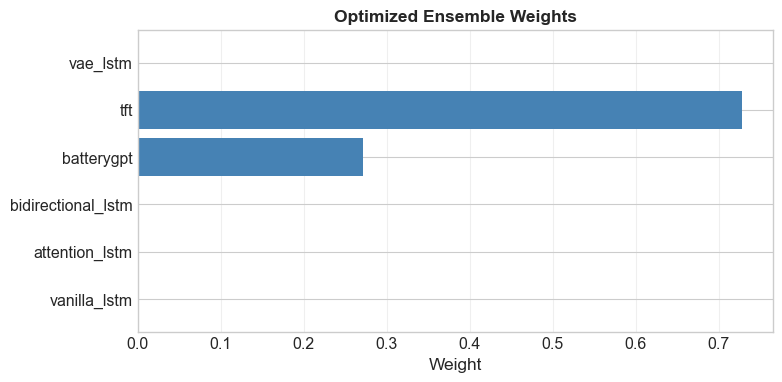

In [5]:
from scipy.optimize import minimize

if len(model_names) >= 2:
    P_test_mat = np.column_stack([predictions_test[n] for n in model_names])
    
    def objective(w):
        w_norm = w / w.sum()
        combined = P_test_mat @ w_norm
        return np.mean(np.abs(combined - y_test))
    
    n_models = len(model_names)
    result = minimize(
        objective,
        x0=np.ones(n_models) / n_models,
        method="L-BFGS-B",
        bounds=[(0.0, 1.0)] * n_models,
    )
    weights = result.x / result.x.sum()
    y_wav = P_test_mat @ weights
    
    m_wav = regression_metrics(y_test, y_wav)
    m_wav["tol_2pct"] = tolerance_accuracy(y_test, y_wav, 2.0)
    
    print("Weighted Average Ensemble (L-BFGS-B optimized):")
    print(f"  Optimal weights:")
    for name, w in zip(model_names, weights):
        print(f"    {name:25s}  {w:.4f}")
    print(f"  MAE  = {m_wav['MAE']:.4f}")
    print(f"  RMSE = {m_wav['RMSE']:.4f}")
    print(f"  R²   = {m_wav['R2']:.4f}")
    print(f"  Tol.Acc (±2%) = {m_wav['tol_2pct']:.2%}")
    
    # Weight bar chart
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(model_names, weights, color="steelblue")
    ax.set_xlabel("Weight"); ax.set_title("Optimized Ensemble Weights", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")
    plt.tight_layout(); save_fig(fig, "v2_ensemble_weights"); plt.show()
else:
    y_wav = None
    m_wav = None

## 5. Comparison: Individual vs Ensemble

,MAE,MSE,RMSE,R2,MAPE,tol_2pct
model,,,,,,
Weighted Avg Ensemble,3.7378,37.7390,6.1432,0.8977,5.4785,0.3483
tft,4.7327,46.6883,6.8329,0.8734,7.4993,0.2138
Stacking Ensemble,5.7691,60.0354,7.7483,0.8372,10.9241,0.1241
vae_lstm,8.4949,100.7867,10.0393,0.7267,14.2501,0.0931
batterygpt,8.0207,129.0695,11.3609,0.6500,12.8743,0.2862
vanilla_lstm,10.5614,155.9577,12.4883,0.5771,14.3751,0.1586
bidirectional_lstm,11.1349,167.3344,12.9358,0.5463,17.1246,0.1069
attention_lstm,14.1813,288.2399,16.9776,0.2184,24.8279,0.1586


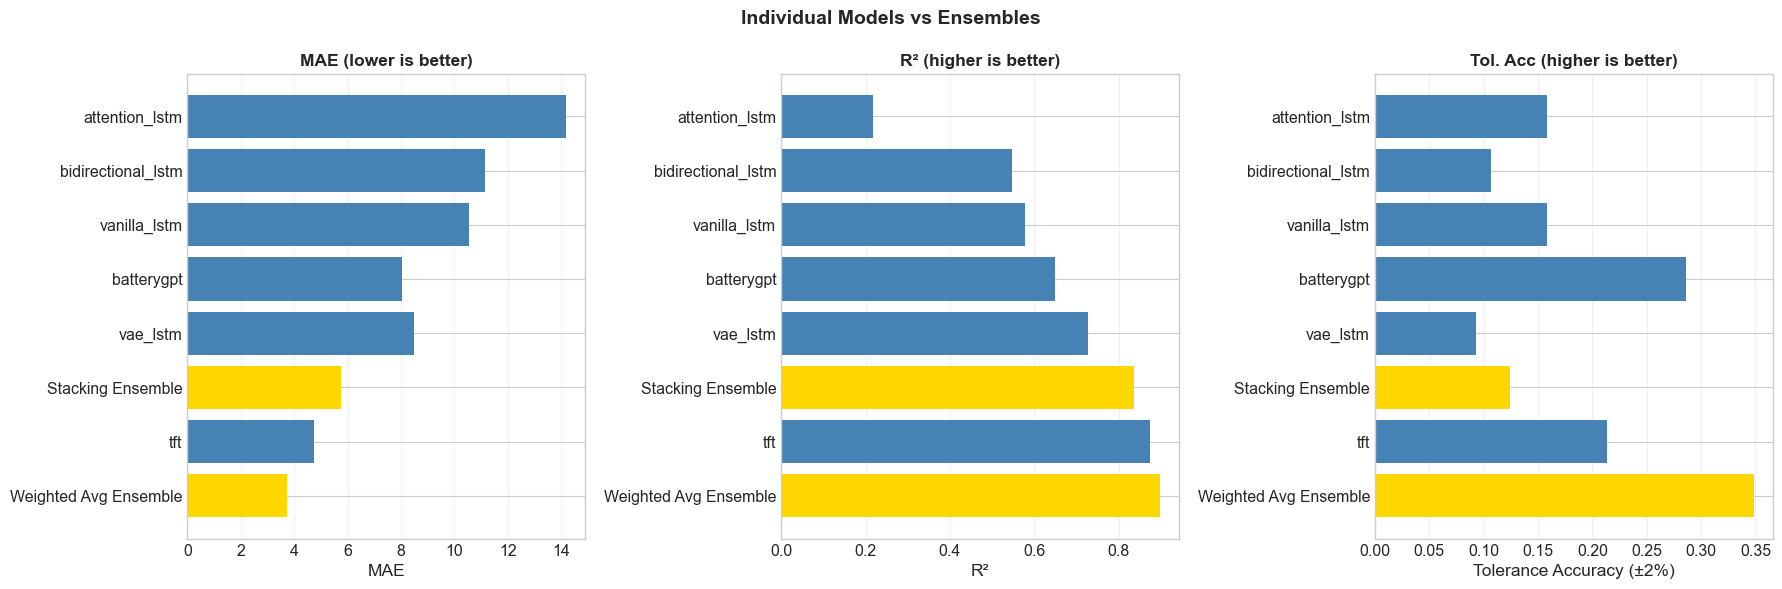


Best model: Weighted Avg Ensemble with R² = 0.8977


In [6]:
# Collect all individual + ensemble results
all_results = {}
for name in model_names:
    m = regression_metrics(y_test, predictions_test[name])
    m["tol_2pct"] = tolerance_accuracy(y_test, predictions_test[name], 2.0)
    all_results[name] = m

if m_stack is not None:
    all_results["Stacking Ensemble"] = m_stack
if m_wav is not None:
    all_results["Weighted Avg Ensemble"] = m_wav

summary = build_summary_table(all_results).sort_values("R2", ascending=False)
display(summary.round(4))
summary.to_csv(v2["results"] / "v2_ensemble_results.csv")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names = summary.index.tolist()
colors = ["gold" if "Ensemble" in n else "steelblue" for n in names]

axes[0].barh(names, summary["MAE"], color=colors)
axes[0].set_xlabel("MAE"); axes[0].set_title("MAE (lower is better)", fontweight="bold")

axes[1].barh(names, summary["R2"], color=colors)
axes[1].set_xlabel("R²"); axes[1].set_title("R² (higher is better)", fontweight="bold")

if "tol_2pct" in summary.columns:
    axes[2].barh(names, summary["tol_2pct"], color=colors)
    axes[2].set_xlabel("Tolerance Accuracy (±2%)")
    axes[2].set_title("Tol. Acc (higher is better)", fontweight="bold")

for ax in axes:
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Individual Models vs Ensembles", fontsize=14, fontweight="bold")
plt.tight_layout(); save_fig(fig, "v2_ensemble_comparison"); plt.show()

print(f"\nBest model: {summary.index[0]} with R² = {summary.iloc[0]['R2']:.4f}")

## 6. Actual vs Predicted — Best Ensemble

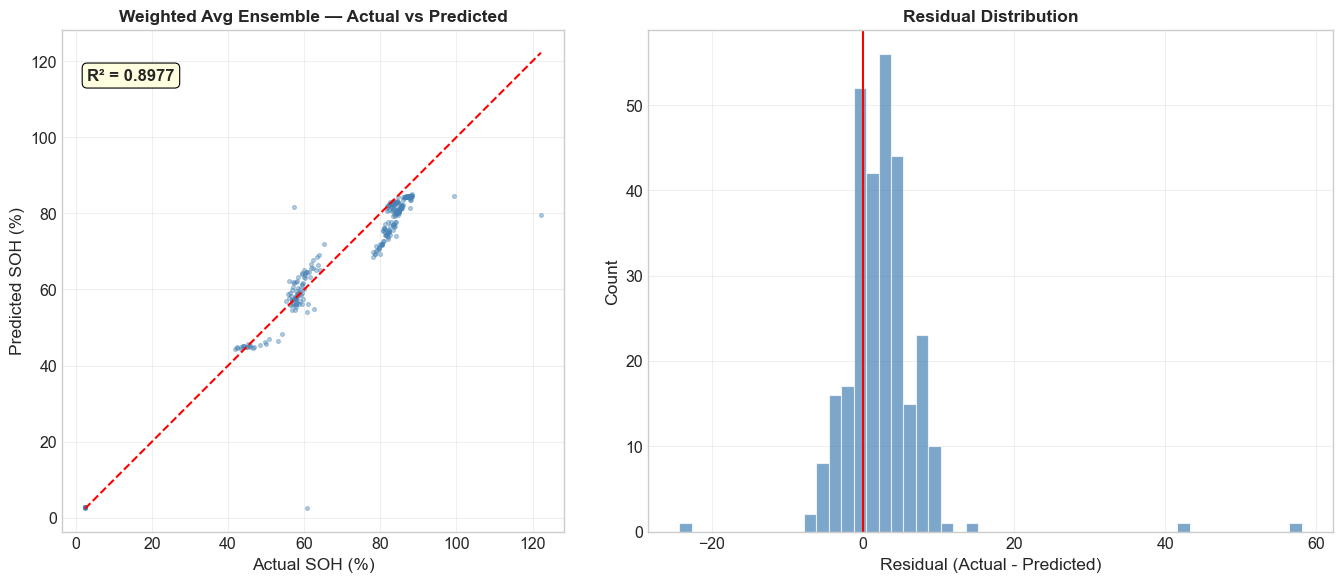

In [7]:
# Pick the best ensemble
if m_wav is not None and m_stack is not None:
    best_name = "Weighted Avg" if m_wav["R2"] > m_stack["R2"] else "Stacking"
    best_pred = y_wav if m_wav["R2"] > m_stack["R2"] else y_stack
    best_metrics = m_wav if m_wav["R2"] > m_stack["R2"] else m_stack
elif m_wav is not None:
    best_name, best_pred, best_metrics = "Weighted Avg", y_wav, m_wav
elif m_stack is not None:
    best_name, best_pred, best_metrics = "Stacking", y_stack, m_stack
else:
    best_name = None

if best_name:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    axes[0].scatter(y_test, best_pred, s=8, alpha=0.4, c="steelblue")
    lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
    axes[0].plot(lims, lims, "r--", linewidth=1.5)
    axes[0].annotate(f"R² = {best_metrics['R2']:.4f}", xy=(0.05, 0.9),
                     xycoords="axes fraction", fontsize=12, fontweight="bold",
                     bbox=dict(boxstyle="round", facecolor="lightyellow"))
    axes[0].set_xlabel("Actual SOH (%)"); axes[0].set_ylabel("Predicted SOH (%)")
    axes[0].set_title(f"{best_name} Ensemble — Actual vs Predicted", fontweight="bold")
    axes[0].set_aspect("equal"); axes[0].grid(True, alpha=0.3)
    
    residuals = y_test - best_pred
    axes[1].hist(residuals, bins=50, color="steelblue", alpha=0.7, edgecolor="white")
    axes[1].axvline(x=0, color="red", linewidth=1.5)
    axes[1].set_xlabel("Residual (Actual - Predicted)")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Residual Distribution", fontweight="bold")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout(); save_fig(fig, "v2_best_ensemble_prediction"); plt.show()